# Week 3


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = 'D:/Interns/Private Data/Week 3/'
file = '20Gsps_shuffled_output_file.xlsx'
file2 = '250Msps_shuffled_output_file.xlsx'

data = pd.read_excel(path+file)

In [16]:
data.head()

,Steady_State,Energy_of_Signal,Energy_of_Envelop,Variance_of_Signal,Entropy_of_Instantaneous_Phase,std_of _Signal,slope_Energy_Distribution,Energy,Variance_of_Energy,Max_sum_energy,3rd_order_poly_coef_3,3rd_order_poly_coef_2,3rd_order_poly_coef_1,3rd_order_poly_coef_c,Device
0,1714,0.041276,0.049968,0.000004,5.410282,0.856949,-0.000045,0.468376,3.127504e-06,0.010239,-5.426167e-13,2.433658e-09,-3.170320e-06,0.005723,Samsung_s3_duos
1,1822,0.066852,0.082562,0.000007,5.612497,1.186138,0.000045,11.719469,7.511305e-06,0.011729,1.555318e-13,-5.425821e-10,5.442698e-07,0.005728,sony_C4
2,1786,0.055996,0.068779,0.000006,5.603773,1.113180,0.000029,0.512190,4.064475e-06,0.010776,-2.312008e-13,8.151912e-10,-8.182898e-07,0.005561,Iphone 7
3,1797,0.048046,0.058018,0.000004,5.338443,0.851986,0.000030,0.393375,1.773436e-06,0.010490,-6.823871e-14,-2.310527e-10,6.892579e-07,0.004722,Iphone 7
4,4065,0.052680,0.056836,0.000001,4.296719,0.343541,0.000008,0.358361,9.748302e-07,0.006737,-2.705015e-15,1.167282e-11,-1.223497e-08,0.003589,Iphone_X


In [17]:
print(data.isnull().sum())
# There are no null values

Steady_State                      0
Energy_of_Signal                  0
Energy_of_Envelop                 0
Variance_of_Signal                0
Entropy_of_Instantaneous_Phase    0
std_of _Signal                    0
slope_Energy_Distribution         0
Energy                            0
Variance_of_Energy                0
Max_sum_energy                    0
3rd_order_poly_coef_3             0
3rd_order_poly_coef_2             0
3rd_order_poly_coef_1             0
3rd_order_poly_coef_c             0
Device                            0
dtype: int64


In [18]:
print(f"Shape of the original data is {data.shape}")
X = data.iloc[:,:-1]
print(f"Size of all data without target columns is {X.shape}")
Y = data.iloc[:,-1]
print(f"Size of target columns is {Y.shape}")

Shape of the original data is (1500, 15)
Size of all data without target columns is (1500, 14)
Size of target columns is (1500,)


In [19]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [20]:
data.iloc[:, -1].value_counts()

Device
Samsung_s3_duos     150
sony_C4             150
Iphone 7            150
Iphone_X            150
Samsung S3          150
LG_G4               150
Samsung S4          150
Iphone 5s           150
Huawei Gr5          150
samsung_note3_20    150
Name: count, dtype: int64

Epoch 1/100
30/30 [==============================] - 3s 39ms/step - loss: 2.3054 - accuracy: 0.1052 - val_loss: 2.3141 - val_accuracy: 0.0958
Epoch 2/100
30/30 [==============================] - 0s 8ms/step - loss: 2.3043 - accuracy: 0.1052 - val_loss: 2.3134 - val_accuracy: 0.0958
Epoch 3/100
30/30 [==============================] - 0s 8ms/step - loss: 2.3036 - accuracy: 0.1052 - val_loss: 2.3129 - val_accuracy: 0.0958
Epoch 4/100
30/30 [==============================] - 0s 9ms/step - loss: 2.3030 - accuracy: 0.1052 - val_loss: 2.3122 - val_accuracy: 0.0958
Epoch 5/100
30/30 [==============================] - 0s 7ms/step - loss: 2.3025 - accuracy: 0.1052 - val_loss: 2.3121 - val_accuracy: 0.0958
Epoch 6/100
30/30 [==============================] - 0s 8ms/step - loss: 2.3024 - accuracy: 0.1052 - val_loss: 2.3118 - val_accuracy: 0.0958
Epoch 7/100
30/30 [==============================] - 0s 10ms/step - loss: 2.3021 - accuracy: 0.1052 - val_loss: 2.3117 - val_accuracy: 0.0958
Epoch 8/100

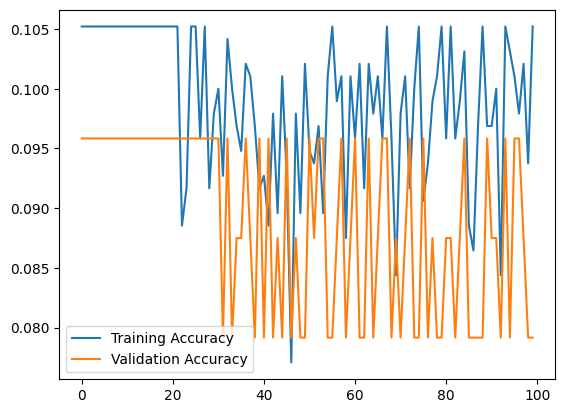

In [21]:
# Fix: Encode string labels to integers before training and specify learning rate

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Encode only the target columns (labels) as integers
le = LabelEncoder()
Y_train_enc = le.fit_transform(Y_train)
Y_test_enc = le.transform(Y_test)

# Specify learning rate for the optimizer
learning_rate = 0.001
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

# Create a small MLP of two layers
model = keras.models.Sequential([
    keras.layers.Dense(12, activation='softmax', input_shape=(X_train.shape[1],)),
    # keras.layers.Dropout(0.3),
    keras.layers.Dense(11, activation='softmax'),
    # keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax'),
    # keras.layers.Dropout(0.1),
    keras.layers.Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, Y_train_enc, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, Y_test_enc, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()

### 250 Msps


Training: lr=0.01, batch=16, units=[32, 16], dropout=0.0


Validation accuracy: 0.0958, Test accuracy: 0.1000

Training: lr=0.01, batch=16, units=[32, 16], dropout=0.2
Validation accuracy: 0.0958, Test accuracy: 0.1000

Training: lr=0.01, batch=16, units=[64, 32], dropout=0.0
Validation accuracy: 0.1458, Test accuracy: 0.0633

Training: lr=0.01, batch=16, units=[64, 32], dropout=0.2
Validation accuracy: 0.0958, Test accuracy: 0.0867

Training: lr=0.01, batch=16, units=[32, 16, 8], dropout=0.0
Validation accuracy: 0.0875, Test accuracy: 0.0933

Training: lr=0.01, batch=16, units=[32, 16, 8], dropout=0.2
Validation accuracy: 0.1458, Test accuracy: 0.0633

Training: lr=0.01, batch=32, units=[32, 16], dropout=0.0
Validation accuracy: 0.0958, Test accuracy: 0.0867

Training: lr=0.01, batch=32, units=[32, 16], dropout=0.2
Validation accuracy: 0.0875, Test accuracy: 0.0933

Training: lr=0.01, batch=32, units=[64, 32], dropout=0.0
Validation accuracy: 0.0958, Test accuracy: 0.0867

Training: lr=0.01, batch=32, units=[64, 32], dropout=0.2
Validation ac

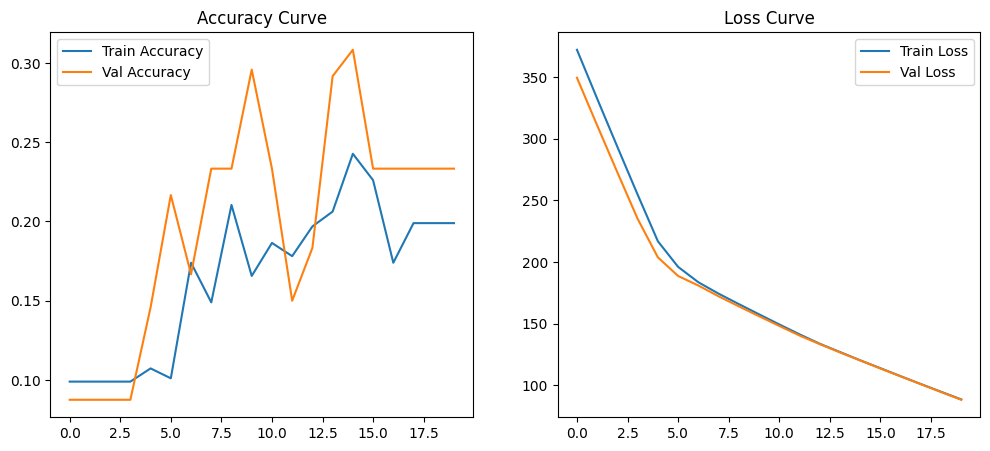


Top 5 Hyperparameter Combinations:
lr=0.0001, batch=64, units=[32, 16], dropout=0.0 -> Val acc: 0.3083, Test acc: 0.2567
lr=0.001, batch=32, units=[64, 32], dropout=0.0 -> Val acc: 0.3250, Test acc: 0.2433
lr=0.0001, batch=32, units=[64, 32], dropout=0.0 -> Val acc: 0.2708, Test acc: 0.2367
lr=0.001, batch=16, units=[64, 32], dropout=0.0 -> Val acc: 0.1958, Test acc: 0.2233
lr=0.001, batch=64, units=[32, 16, 8], dropout=0.0 -> Val acc: 0.1667, Test acc: 0.1900


In [22]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import keras
from keras.callbacks import EarlyStopping

# Encode only the target columns (labels) as integers
le = LabelEncoder()
Y_train_enc = le.fit_transform(Y_train)
Y_test_enc = le.transform(Y_test)

# Hyperparameter grid
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [16, 32, 64]
hidden_units = [
    [32, 16],   # 2 layers: 32, 16
    [64, 32],   # 2 layers: 64, 32
    [32, 16, 8] # 3 layers: 32, 16, 8
]
dropout_rates = [0.0, 0.2]  # Added dropout for better generalization

results = []

for lr in learning_rates:
    for batch_size in batch_sizes:
        for units in hidden_units:
            for dropout in dropout_rates:
                # Build model
                model = keras.models.Sequential()
                model.add(keras.layers.Input(shape=(X_train.shape[1],)))
                for u in units:
                    model.add(keras.layers.Dense(u, activation='relu'))
                    if dropout > 0:
                        model.add(keras.layers.Dropout(dropout))
                model.add(keras.layers.Dense(len(le.classes_), activation='softmax'))

                optimizer = keras.optimizers.Adam(learning_rate=lr)
                model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

                print(f"\nTraining: lr={lr}, batch={batch_size}, units={units}, dropout={dropout}")

                # Early stopping to avoid overfitting
                es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=0)

                history = model.fit(
                    X_train, Y_train_enc,
                    epochs=50,
                    batch_size=batch_size,
                    validation_split=0.2,
                    callbacks=[es],
                    verbose=0
                )

                test_loss, test_acc = model.evaluate(X_test, Y_test_enc, verbose=0)
                best_val_acc = max(history.history['val_accuracy'])

                print(f"Validation accuracy: {best_val_acc:.4f}, Test accuracy: {test_acc:.4f}")

                results.append({
                    'learning_rate': lr,
                    'batch_size': batch_size,
                    'hidden_units': units,
                    'dropout': dropout,
                    'val_accuracy': best_val_acc,
                    'test_accuracy': test_acc,
                    'history': history
                })

# Sort results by test accuracy (descending)
results.sort(key=lambda x: x['test_accuracy'], reverse=True)

# Best run
best_run = results[0]
print("\nBest Run:")
print(f"lr={best_run['learning_rate']}, batch={best_run['batch_size']}, units={best_run['hidden_units']}, "
      f"dropout={best_run['dropout']} -> Test accuracy: {best_run['test_accuracy']:.4f}")

# Plot accuracy and loss curves for best run
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(best_run['history'].history['accuracy'], label='Train Accuracy')
plt.plot(best_run['history'].history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(best_run['history'].history['loss'], label='Train Loss')
plt.plot(best_run['history'].history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()

# Print top 5 results summary
print("\nTop 5 Hyperparameter Combinations:")
for r in results[:5]:
    print(f"lr={r['learning_rate']}, batch={r['batch_size']}, units={r['hidden_units']}, dropout={r['dropout']} "
          f"-> Val acc: {r['val_accuracy']:.4f}, Test acc: {r['test_accuracy']:.4f}")


Epoch 1/350
30/30 [==============================] - 2s 21ms/step - loss: 69.9685 - accuracy: 0.1177 - val_loss: 23.9445 - val_accuracy: 0.1458
Epoch 2/350
30/30 [==============================] - 0s 6ms/step - loss: 18.7440 - accuracy: 0.1167 - val_loss: 13.0179 - val_accuracy: 0.1458
Epoch 3/350
30/30 [==============================] - 0s 7ms/step - loss: 8.1694 - accuracy: 0.1260 - val_loss: 3.0864 - val_accuracy: 0.1833
Epoch 4/350
30/30 [==============================] - 0s 6ms/step - loss: 3.8589 - accuracy: 0.1156 - val_loss: 2.8276 - val_accuracy: 0.1042
Epoch 5/350
30/30 [==============================] - 0s 7ms/step - loss: 2.7167 - accuracy: 0.1844 - val_loss: 2.3310 - val_accuracy: 0.3167
Epoch 6/350
30/30 [==============================] - 1s 20ms/step - loss: 2.6212 - accuracy: 0.1885 - val_loss: 2.5903 - val_accuracy: 0.2458
Epoch 7/350
30/30 [==============================] - 1s 30ms/step - loss: 3.1894 - accuracy: 0.1677 - val_loss: 3.0827 - val_accuracy: 0.2333
Epoch 

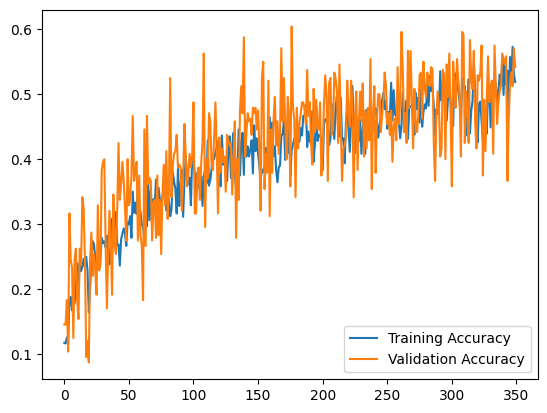

In [23]:
# Implement: lr=0.001, batch=32, units=[64, 32], dropout=0.0, epochs=200

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Encode only the target columns (labels) as integers
le = LabelEncoder()
Y_train_enc = le.fit_transform(Y_train)
Y_test_enc = le.transform(Y_test)

# Specify learning rate for the optimizer
learning_rate = 0.001
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

# Create an MLP with two hidden layers: 64 and 32 units, no dropout
model = keras.models.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model with batch_size=32, epochs=200
history = model.fit(X_train, Y_train_enc, epochs=350, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, Y_test_enc, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()

### 20GSps


Best Hyperparameters found:
lr=0.001, batch=16, units=[32, 16], dropout=0.0 -> Test accuracy: 0.3333
Epoch 1/300
60/60 [==============================] - 7s 38ms/step - loss: 49.5512 - accuracy: 0.1031 - val_loss: 18.7500 - val_accuracy: 0.0833
Epoch 2/300
60/60 [==============================] - 1s 14ms/step - loss: 9.9737 - accuracy: 0.1177 - val_loss: 3.3332 - val_accuracy: 0.2292
Epoch 3/300
60/60 [==============================] - 1s 12ms/step - loss: 2.4408 - accuracy: 0.0969 - val_loss: 2.3105 - val_accuracy: 0.0958
Epoch 4/300
60/60 [==============================] - 1s 10ms/step - loss: 2.3044 - accuracy: 0.0979 - val_loss: 2.3103 - val_accuracy: 0.0875
Epoch 5/300
60/60 [==============================] - 1s 19ms/step - loss: 2.3042 - accuracy: 0.1052 - val_loss: 2.3104 - val_accuracy: 0.0875
Epoch 6/300
60/60 [==============================] - 1s 14ms/step - loss: 2.3040 - accuracy: 0.1010 - val_loss: 2.3104 - val_accuracy: 0.0958
Epoch 7/300
60/60 [=========================

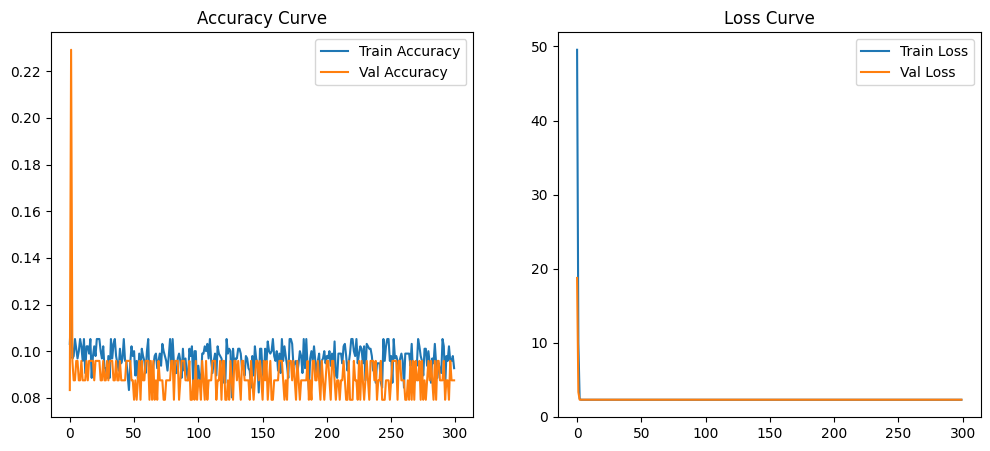

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = 'D:/Interns/Private Data/Week 3/'
file = '20Gsps_shuffled_output_file.xlsx'
file2 = '250Msps_shuffled_output_file.xlsx'

data = pd.read_excel(path+file2)

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

# Assume X, Y are already defined from your data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

from sklearn.preprocessing import LabelEncoder

# Encode only the target columns (labels) as integers
le = LabelEncoder()
Y_train_enc = le.fit_transform(Y_train)
Y_test_enc = le.transform(Y_test)

# Hyperparameter grid
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [16, 32, 64]
hidden_units = [
    [32, 16],   # 2 layers: 32, 16
    [64, 32],   # 2 layers: 64, 32
    [32, 16, 8] # 3 layers: 32, 16, 8
]
dropout_rates = [0.0, 0.2]  # Added dropout for better generalization

results = []

# Hyperparameter search (short training for speed)
for lr in learning_rates:
    for batch_size in batch_sizes:
        for units in hidden_units:
            for dropout in dropout_rates:
                # Build model
                model = keras.models.Sequential()
                model.add(keras.layers.Input(shape=(X_train.shape[1],)))
                for u in units:
                    model.add(keras.layers.Dense(u, activation='relu'))
                    if dropout > 0:
                        model.add(keras.layers.Dropout(dropout))
                model.add(keras.layers.Dense(len(le.classes_), activation='softmax'))

                optimizer = keras.optimizers.Adam(learning_rate=lr)
                model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

                # No early stopping
                history = model.fit(
                    X_train, Y_train_enc,
                    epochs=50,
                    batch_size=batch_size,
                    validation_split=0.2,
                    verbose=0
                )

                test_loss, test_acc = model.evaluate(X_test, Y_test_enc, verbose=0)
                best_val_acc = max(history.history['val_accuracy'])

                results.append({
                    'learning_rate': lr,
                    'batch_size': batch_size,
                    'hidden_units': units,
                    'dropout': dropout,
                    'val_accuracy': best_val_acc,
                    'test_accuracy': test_acc
                })

# Sort results by test accuracy (descending)
results.sort(key=lambda x: x['test_accuracy'], reverse=True)

# Get best hyperparameters
best_params = results[0]
print("\nBest Hyperparameters found:")
print(f"lr={best_params['learning_rate']}, batch={best_params['batch_size']}, units={best_params['hidden_units']}, "
      f"dropout={best_params['dropout']} -> Test accuracy: {best_params['test_accuracy']:.4f}")

# Retrain model with best hyperparameters and 300 epochs
model = keras.models.Sequential()
model.add(keras.layers.Input(shape=(X_train.shape[1],)))
for u in best_params['hidden_units']:
    model.add(keras.layers.Dense(u, activation='relu'))
    if best_params['dropout'] > 0:
        model.add(keras.layers.Dropout(best_params['dropout']))
model.add(keras.layers.Dense(len(le.classes_), activation='softmax'))

optimizer = keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# No early stopping
history = model.fit(
    X_train, Y_train_enc,
    epochs=300,
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, Y_test_enc, verbose=0)
print(f"\nFinal Test accuracy with best hyperparameters: {test_acc:.4f}")

# Plot accuracy and loss curves for the final model
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()
